In [70]:
%reset -f

from glob import glob

import easygui
import matplotlib.pyplot as plt
import numpy as np
from VicPy import VicDataSet
from geomfitty import geom3d, fit3d
from scipy.io import loadmat


In [71]:
# Declare constants

plt.rcParams["font.family"] = "serif"

DATA_DIR = easygui.diropenbox("Select Folder with out-Files")

YAW_ANGLE_FLAG = False
if YAW_ANGLE_FLAG:
    yaw_angle_file = easygui.fileopenbox("Select the Yaw Angle Time-Series File")
else:
    pass


In [72]:
out_file_list = glob(DATA_DIR + "/*.out")
frame_n = 2979 # len(out_file_list)

if YAW_ANGLE_FLAG:
    yaw_angle_array = np.array(loadmat(yaw_angle_file)["yaw_wea"])[:frame_n].flatten()

    yaw_angle_mean = np.mean(yaw_angle_array)
    yaw_angle_med = np.median(yaw_angle_array)

    fig1, ax1 = plt.subplots()
    ax1.plot(yaw_angle_array)
    ax1.set_xlim(0)
    ax1.set_xlabel("Frame")
    ax1.set_ylabel("Yaw Angle [°]")
    ax1.grid()

    fig2, ax2 = plt.subplots()
    ax2.hist(yaw_angle_array, bins=5)
    ax2.set_ylabel("Frequency")
    ax2.set_xlabel("Yaw Angle [°]")

    z_rot_angle_array = yaw_angle_array - yaw_angle_med

    z_rot_matrix_list = []
    for z_rot_angle in z_rot_angle_array:
        rot_z = np.array([[np.cos(z_rot_angle), -np.sin(z_rot_angle), 0],
                          [np.sin(z_rot_angle), np.cos(z_rot_angle), 0],
                          [0, 0, 1]])
        z_rot_matrix_list.append(rot_z)

else:
    pass

In [73]:
def read_file(file_name):

    data = VicDataSet()  # Creates an instance of a VicDataSet() class

    if not data.load(file_name):  # Tries to load a .out file into the VicDataSet() instance, it exits if it fails
        print("Could not load data set\n\n")
        exit(-1)

    size = 0
    for aoi in range(data.numData()):  # The numData() method returns the number of areas of interest in the dataset
        d = data.data(aoi)  # Returns a pointer to VicData objet for the specific AOI in the dataset
        size += d.matrixSize()

    found_array = np.empty((size), int)  # gibt an, ob ein Subset gefunden wurde. 1 wenn gefunden, sonst 0
    coordinates = np.empty((size, 3), float)  # enthaelt die Koordinaten der Subsets
    xyz_sigmas = np.empty((size, 3), float)  # enthaelt die Sigma-Werte eines Subsets
    aoi_number = np.empty((size), int)  # gibt an in welcher AOI ein Subset liegt
    index_in_aoi = np.empty((size), int)  # Index des Subsets innerhalb der AOI

    index = 0
    for aoi in range(data.numData()):
        d = data.data(aoi)
        rows = d.asArray(["sigma", "X", "Y", "Z", "U", "V", "W", "SIGMA_X", "SIGMA_Y",
                          "SIGMA_Z"])  #TODO: This array is the same as the hardcoded one on top?
        rows = rows.view(np.float32).reshape(rows.shape[0], -1)

        rows = rows.T  # TODO: I'm pretty sure this transpose is not needed
        found_array_for_aoi = np.where(rows[0] < 0, 0, 1)

        coordinates_for_aoi = (rows[1:4] + rows[4:7]).T
        xyz_sigma_for_aoi = rows[7:10].T

        found_array[index: index + len(found_array_for_aoi)] = found_array_for_aoi
        coordinates[index: index + len(coordinates_for_aoi)] = coordinates_for_aoi
        xyz_sigmas[index: index + len(xyz_sigma_for_aoi)] = xyz_sigma_for_aoi
        aoi_number[index: index + len(xyz_sigma_for_aoi)] = np.full((len(xyz_sigma_for_aoi)),
                                                                    aoi)
        index_in_aoi[index: index + len(xyz_sigma_for_aoi)] = np.arange(len(found_array_for_aoi))

        index += len(found_array_for_aoi)

    return found_array, coordinates, xyz_sigmas, aoi_number, index_in_aoi


[ 0.05502 -0.3994  -0.91513]
[ 0.99186898  0.12688786 -0.00976747]
[-0.99194842  0.10267    -0.07414308]


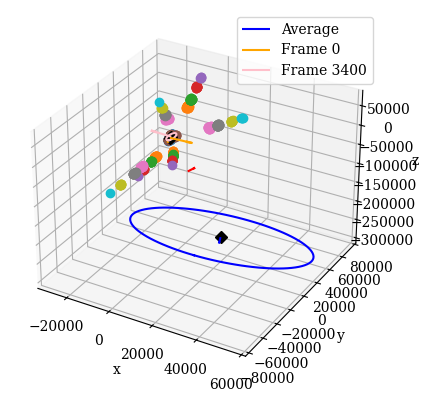

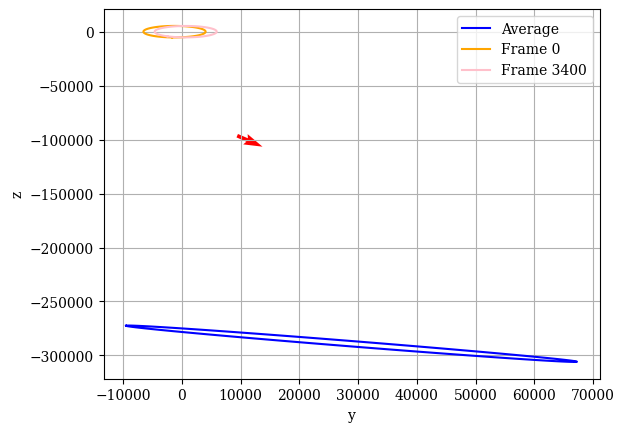

In [74]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(projection="3d")

fig2 = plt.figure()
ax2 = fig2.add_subplot()

circle_dir_list = [np.array([0.05502, -0.39940, -0.91513])]
circle_center_list = [np.array([13960.16956, 28868.63545, -289172.31680])]
needed_angle_list = []
rot_axis_list = []

for out_file in out_file_list:
    found_array, coordinates, xyz_sigmas, aoi_number, index_in_aoi = read_file(out_file)

    aoi_mean_coord = []
    for aoi in np.unique(aoi_number):
        bool_mask = (aoi_number == aoi) & (found_array > 0)
        aoi_mean_coord.append(np.mean(coordinates[bool_mask, :][::100], axis=0))

    aoi_mean_coord = np.array(aoi_mean_coord)
    center_point = np.mean(aoi_mean_coord, axis=0)

    dist_array = np.linalg.norm(aoi_mean_coord - center_point, axis=1)
    arg_dist = np.argsort(dist_array)

    dist_array = dist_array[arg_dist]

    for i in range(5):
        bool_mask = ((aoi_number == arg_dist[3*i]) | (aoi_number == arg_dist[3*i+1]) | (aoi_number == arg_dist[3*i+2])) & (found_array > 0)
        ax1.plot(coordinates[bool_mask
        , 0][::100], coordinates[bool_mask, 1][::100], coordinates[bool_mask, 2][::100], linestyle='', marker='o', alpha=1)


    inner_rad = np.mean(dist_array[:3])/1000
    initial_guess = geom3d.Circle3D(center_point, [1, 0, 0], inner_rad)
    circle = fit3d.circle3D_fit(coordinates[((aoi_number == arg_dist[0]) | (aoi_number == arg_dist[1]) | (aoi_number == arg_dist[2])) & (found_array > 0)], initial_guess=initial_guess)

    circle_center_list.append(circle.center)
    circle_dir_list.append(circle.direction)

    needed_angle = np.rad2deg(np.arccos(np.dot(circle.direction, circle_dir_list[0])/(np.linalg.norm(circle_dir_list[0])*np.linalg.norm(circle.direction))))

    if needed_angle > 90:
        needed_angle = needed_angle - 180
    else:
        pass

    needed_angle_list.append(needed_angle)

    rot_axis = np.cross(circle.direction, circle_dir_list[0]) / np.linalg.norm(np.cross(circle.direction, circle_dir_list[0]))
    rot_axis_list.append(rot_axis)


circle_center_array = np.array(circle_center_list)
circle_dir_array = np.array(circle_dir_list)
circle_dir_array[-1] = -1*circle_dir_array[-1]

color_list = ["blue", "orange", "pink"]
legend_list = ["Average", "Frame 0", "Frame 3400"]
for i in range(len(circle_center_array)):

    random = np.array([1, 0, 0])
    u = np.cross(circle_dir_array[i], random)
    v = np.cross(circle_dir_array[i], u)
    theta = np.linspace(0, 2 * np.pi, 100)

    circle_pts = 41905 * (np.outer(u, np.cos(theta)) + np.outer(v, np.sin(theta)))
    circle_pts = circle_center_array[i] + circle_pts.T

    ax1.plot(circle_center_array[i][0], circle_center_array[i][1], circle_center_array[i][2], marker='D', color='black')

    ax1.plot(circle_pts[:, 0],circle_pts[:, 1],circle_pts[:, 2], color_list[i])

    ax1.quiver(circle_center_array[i][0], circle_center_array[i][1], circle_center_array[i][2], circle_dir_array[i][0]*10000, circle_dir_array[i][1]*10000, circle_dir_array[i][2]*10000, color=color_list[i], label=legend_list[i])



    ax2.plot(circle_pts[:, 1], circle_pts[:, 2], color=color_list[i])


    print(circle_dir_array[i])

ax1.quiver(np.mean(circle_center_array, axis=0)[0], np.mean(circle_center_array, axis=0)[1], np.mean(circle_center_array, axis=0)[2], 0.0371*10000, 0.9168*10000, -0.3979*10000, color="red")

ax2.quiver(np.mean(circle_center_array, axis=0)[1], np.mean(circle_center_array, axis=0)[2], 0.9168*10000, -0.3979*10000, color="red")

ax1.legend()
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2.legend(legend_list)
ax2.set_xlabel("y")
ax2.set_ylabel("z")
ax2.grid()




E:\HiWi Cordova\Messung 19_noyaw\comparisson\messung19_003400_0.out
E:\HiWi Cordova\Messung 19_noyaw\comparisson\messung19_003400_0_w_yaw.out


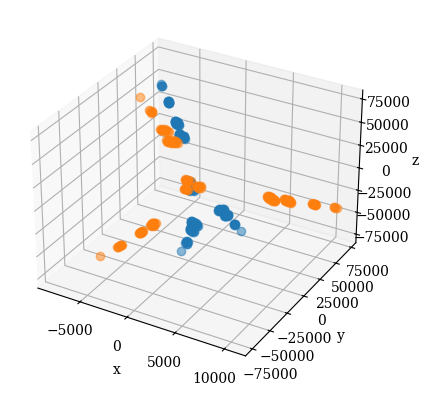

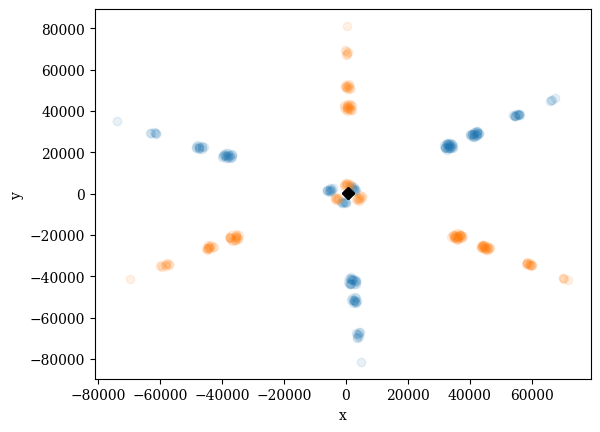

In [75]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(projection="3d")

fig2 = plt.figure()
ax2 = fig2.add_subplot()


for out_file in out_file_list:
    print(out_file)
    found_array, coordinates, xyz_sigmas, aoi_number, index_in_aoi = read_file(out_file)

    aoi_mean_coord = []
    for aoi in np.unique(aoi_number):
        bool_mask = (aoi_number == aoi) & (found_array > 0)
        aoi_mean_coord.append(np.mean(coordinates[bool_mask, :][::100], axis=0))

    aoi_mean_coord = np.array(aoi_mean_coord)
    center_point = np.mean(aoi_mean_coord, axis=0)

    dist_array = np.linalg.norm(aoi_mean_coord - center_point, axis=1)
    arg_dist = np.argsort(dist_array)

    dist_array = dist_array[arg_dist]

    ax1.plot(coordinates[found_array > 0, 0][::100], coordinates[found_array > 0, 1][::100], coordinates[found_array > 0, 2][::100], linestyle='', marker='o', alpha=0.5)
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("z")

    ax2.plot(coordinates[found_array > 0, 1][::100], coordinates[found_array > 0, 2][::100], linestyle='', marker='o', alpha=0.1)



    ax2.plot(circle.center[1], circle.center[2], marker='D', color='black')
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")

